## Key Insights

1. **Sales distribution is right-skewed** — most orders are low-value, with a small number of high-value outliers pulling the average up.

2. **Office Supplies leads in total sales**, followed by Furniture and Technology, though Technology likely has higher profit margins per unit (worth checking with a Profit analysis).

3. **Clear seasonal pattern** — sales spike sharply every November-December, likely due to holiday shopping, and dip in January-February each year.

4. **Overall upward trend** — sales in Nov/Dec 2018 are noticeably higher than in Nov/Dec 2015-2017, suggesting business growth year over year.

5. **11 missing Postal Code values** were found and filled using the mode; no duplicate rows existed in the dataset.

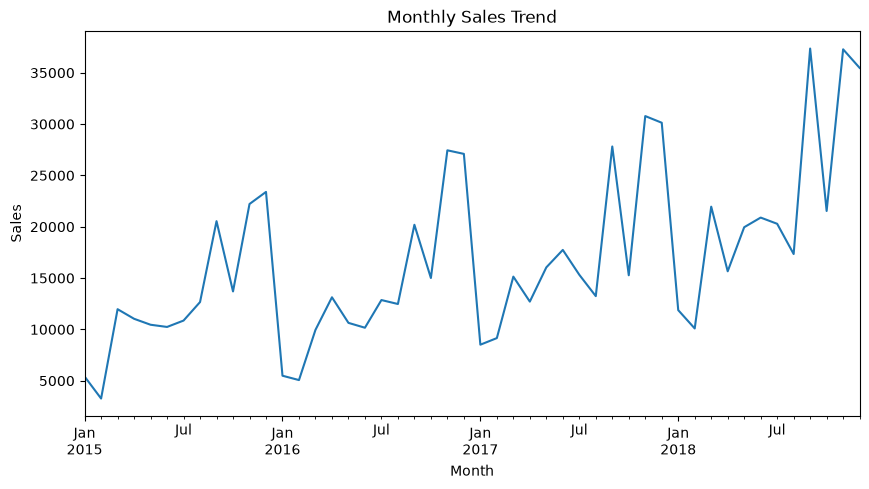

In [14]:
# Line chart - Monthly sales trend
plt.figure(figsize=(10,5))
df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

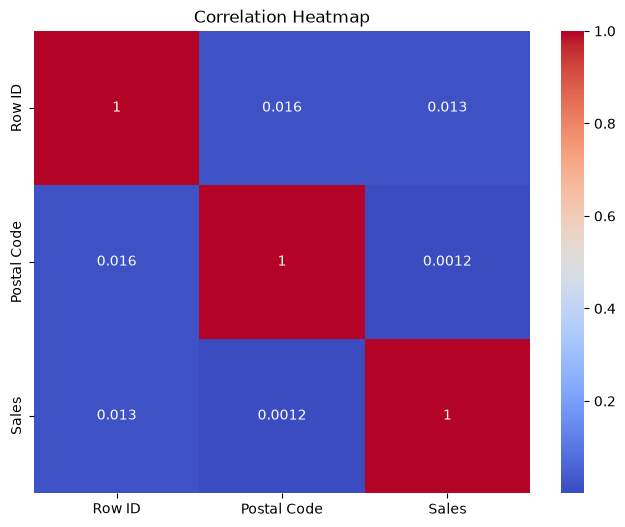

In [13]:
# Heatmap - correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

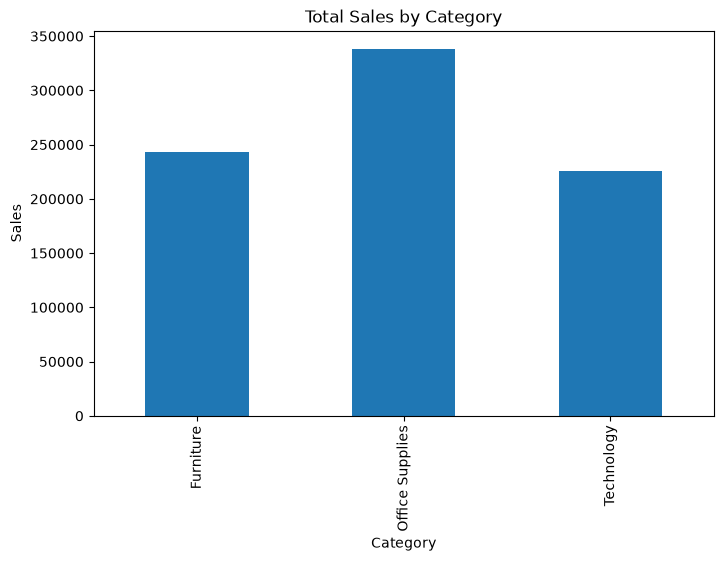

In [12]:
# Bar chart - Sales by Category
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.show()

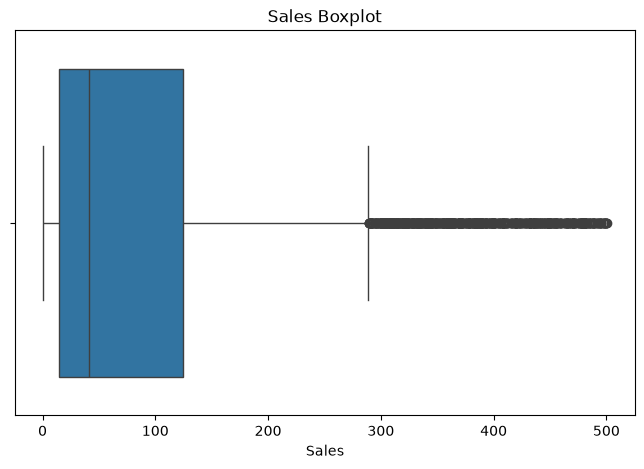

In [11]:
# Boxplot - Sales
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title('Sales Boxplot')
plt.show()

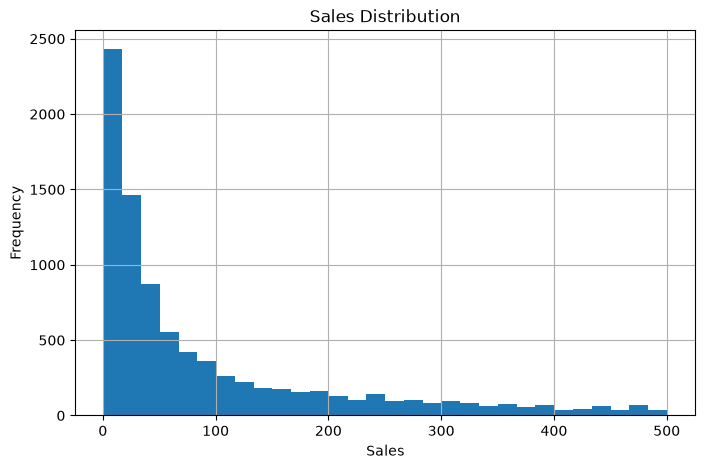

In [10]:
# Histogram - Sales distribution
plt.figure(figsize=(8,5))
df['Sales'].hist(bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,8655.000000,8655,8655,8655.000000,8655.000000
mean,4916.320508,2017-05-04 04:21:32.755632896,2017-05-08 03:36:17.469670656,55395.608781,93.213330
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2454.500000,2016-05-29 00:00:00,2016-06-02 00:00:00,23320.000000,15.014000
50%,4925.000000,2017-07-01 00:00:00,2017-07-03 00:00:00,60025.000000,40.880000
75%,7362.500000,2018-05-18 00:00:00,2018-05-21 12:00:00,90004.000000,124.382000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,500.240000
std,2830.949018,NaN,NaN,31971.352736,114.693292


In [8]:
# Save cleaned dataset
df.to_csv('../data/cleaned_superstore.csv', index=False)
print("Cleaned dataset saved!")

Cleaned dataset saved!


In [7]:
# Handle outliers in Sales using IQR method
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Rows before removing outliers:", df.shape[0])

df = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

print("Rows after removing outliers:", df.shape[0])

Lower bound: -272.7875000000001
Upper bound: 500.6405000000001
Rows before removing outliers: 9800
Rows after removing outliers: 8655


In [6]:
# Handle missing values - Postal Code missing, fill with mode
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mode()[0])

# Remove duplicates (none found, but good practice)
df = df.drop_duplicates()

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [5]:
# Check missing values
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows: 0


In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
